In [1]:
# ===== CELDA 1: Setup PyTorch + checks =====
import os, sys, random, platform
import numpy as np

SEED = 42

# Reproducibilidad
random.seed(SEED)
np.random.seed(SEED)

import torch

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Para resultados más estables (algo más lento)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")  
else:
    device = torch.device("cpu")

print("✅ Python:", sys.version.split()[0])
print("✅ Platform:", platform.platform())
print("✅ Seed:", SEED)
print("✅ NumPy:", np.__version__)
print("✅ PyTorch:", torch.__version__)
print("✅ Device:", device)

if device.type == "cuda":
    print("✅ GPU:", torch.cuda.get_device_name(0))
    print("✅ CUDA:", torch.version.cuda)
    print("✅ cuDNN:", torch.backends.cudnn.version())
elif device.type == "mps":
    print("✅ MPS available (Apple Silicon)")
else:
    print("✅ Running on CPU")


✅ Python: 3.10.7
✅ Platform: Windows-10-10.0.26200-SP0
✅ Seed: 42
✅ NumPy: 2.2.6
✅ PyTorch: 2.9.1+cpu
✅ Device: cpu
✅ Running on CPU


✅ df_raw shape: (185168, 9)
✅ df_raw columns: ['symbol', 'datetime', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap']

✅ df shape: (185167, 17)
✅ df columns: ['symbol', 'datetime', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'volume_norm', 'return', 'log_return_raw', 'log_return_close', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl']
✅ datetime range: 2022-01-03 09:05:00+00:00 → 2025-11-28 21:55:00+00:00
✅ approx bar size (mode): 0 days 00:05:00

Top NaNs:


symbol            0
datetime          0
open              0
high              0
low               0
close             0
volume            0
trade_count       0
vwap              0
volume_norm       0
return            0
log_return_raw    0
dtype: int64

,symbol,datetime,open,high,low,close,volume,trade_count,vwap,volume_norm,return,log_return_raw,log_return_close,log_ret_oc,log_ret_hl,log_ret_ch,log_ret_cl
0,QQQ,2022-01-03 09:05:00+00:00,399.3900,399.40,399.2500,399.4000,7602.0,93.0,399.340687,-0.592960,0.000000e+00,5.989963,0.000000e+00,0.000025,0.000376,0.000000e+00,0.000376
1,QQQ,2022-01-03 09:10:00+00:00,399.3900,399.53,399.3800,399.5300,7260.0,53.0,399.424946,-0.593720,3.254882e-04,5.990289,3.254353e-04,0.000350,0.000376,0.000000e+00,0.000376
2,QQQ,2022-01-03 09:15:00+00:00,399.5400,399.56,399.3400,399.3500,6878.0,112.0,399.470116,-0.594568,-4.505294e-04,5.989838,-4.506309e-04,-0.000476,0.000551,-5.257163e-04,0.000025
3,QQQ,2022-01-03 09:20:00+00:00,399.3300,399.49,399.3000,399.4900,7998.0,48.0,399.398335,-0.592081,3.505697e-04,5.990189,3.505082e-04,0.000401,0.000476,0.000000e+00,0.000476
4,QQQ,2022-01-03 09:25:00+00:00,399.4800,399.48,399.4000,399.4000,1444.0,30.0,399.447894,-0.606631,-2.252872e-04,5.989963,-2.253126e-04,-0.000200,0.000200,-2.002804e-04,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185162,QQQ,2025-11-28 21:35:00+00:00,619.0400,619.09,619.0400,619.0800,608.0,28.0,619.082265,-0.608487,-3.230496e-05,6.428235,-3.230548e-05,0.000065,0.000081,-1.615287e-05,0.000065
185163,QQQ,2025-11-28 21:40:00+00:00,619.0497,619.08,619.0100,619.0796,3219.0,50.0,619.075416,-0.602690,-6.461200e-07,6.428234,-6.461203e-07,0.000048,0.000113,-6.461203e-07,0.000112
185164,QQQ,2025-11-28 21:45:00+00:00,619.0691,619.25,619.0691,619.2100,4562.0,87.0,619.147342,-0.599709,2.106353e-04,6.428444,2.106131e-04,0.000228,0.000292,-6.459635e-05,0.000228
185165,QQQ,2025-11-28 21:50:00+00:00,619.2000,619.23,619.1600,619.1700,1828.0,45.0,619.181573,-0.605778,-6.459844e-05,6.428380,-6.460053e-05,-0.000048,0.000113,-9.689922e-05,0.000016



✅ Close candidates: ['close']


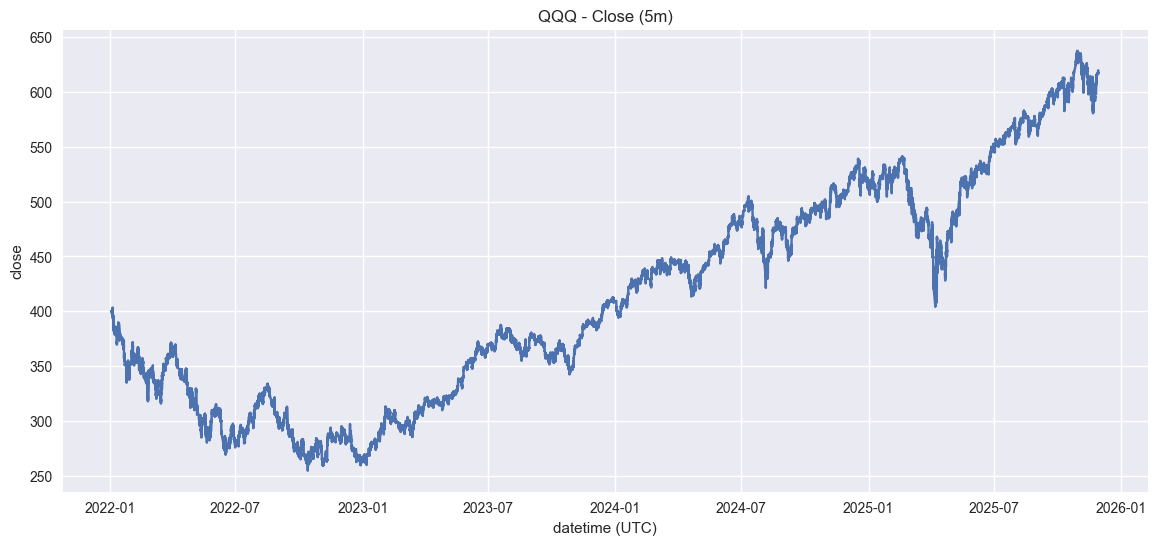

In [2]:
# ===== CELDA 2: Cargar datos (Alpaca) + checks =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath("../src"))
from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True

# Si necesitas importar estas clases/funciones desde tu módulo, descomenta:
# from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data

cfg = DataCleanerConfig(
    source="alpaca",
    symbol="QQQ",
    interval="5m",
    start_date="2022-01-01",
    end_date="2025-12-01",
)

cleaner = DataCleaner(cfg)

df_raw = cleaner.cargar_datos()
print("✅ df_raw shape:", df_raw.shape)
print("✅ df_raw columns:", list(df_raw.columns))

df = preprocess_data(df_raw)

# Normalizamos datetime
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = (
    df.dropna(subset=["datetime"])
      .sort_values("datetime")
      .drop_duplicates("datetime")
      .reset_index(drop=True)
)

print("\n✅ df shape:", df.shape)
print("✅ df columns:", list(df.columns))
print("✅ datetime range:", df["datetime"].min(), "→", df["datetime"].max())

# Check de frecuencia real (aprox)
if len(df) > 5:
    diffs = df["datetime"].diff().dropna()
    mode_diff = diffs.mode().iloc[0] if not diffs.mode().empty else diffs.median()
    print("✅ approx bar size (mode):", mode_diff)

# NaNs
nan_counts = df.isna().sum().sort_values(ascending=False)
print("\nTop NaNs:")
display(nan_counts.head(12))

# Preview
display(df)

# Plot rápido si existe columna close
close_candidates = [c for c in df.columns if c.lower() in ["close", "c", "price", "last", "adj_close", "adj close"]]
print("\n✅ Close candidates:", close_candidates)

if "close" in [c.lower() for c in df.columns]:
    # encuentra el nombre real de la columna close respetando mayúsculas
    close_col = [c for c in df.columns if c.lower() == "close"][0]
    plt.figure(figsize=(14,6))
    plt.plot(df["datetime"], df[close_col])
    plt.title(f"{cfg.symbol} - Close ({cfg.interval})")
    plt.xlabel("datetime (UTC)")
    plt.ylabel("close")
    plt.show()
else:
    print("⚠️ No veo columna 'close'. Dime cuál es la columna de precio y lo mapeamos.")


✅ Columnas disponibles: ['symbol', 'datetime', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'volume_norm', 'return', 'log_return_raw', 'log_return_close', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl']
✅ price_col detectada: close

--- TIME CHECKS ---
✅ datetime monotónica creciente: True
✅ rango: 2022-01-03 09:05:00+00:00 → 2025-11-28 21:55:00+00:00
✅ duplicados datetime: 0
✅ bar size aprox (mode): 0 days 00:05:00

--- VALUE CHECKS ---
✅ n filas: 185167
✅ precio min/mean/max: 254.84 413.83997212840296 637.39
✅ NaNs totales: 0

--- TARGET CHECKS ---
✅ df_base shape: (185165, 21)
✅ y_dir balance (mean=prob subida): 0.4973
✅ columnas finales: ['datetime', 'close', 'ret_1', 'logret_1', 'y_fwd_price', 'y_dir']


,datetime,close,ret_1,logret_1,y_fwd_price,y_dir
0,2022-01-03 09:10:00+00:00,399.53,0.000325,0.000325,399.35,0
1,2022-01-03 09:15:00+00:00,399.35,-0.000451,-0.000451,399.49,1
2,2022-01-03 09:20:00+00:00,399.49,0.000351,0.000351,399.40,0
3,2022-01-03 09:25:00+00:00,399.40,-0.000225,-0.000225,399.34,0
4,2022-01-03 09:30:00+00:00,399.34,-0.000150,-0.000150,399.43,1


,datetime,close,ret_1,logret_1,y_fwd_price,y_dir
185160,2025-11-28 21:30:00+00:00,619.1000,1.130801e-04,1.130737e-04,619.0800,0
185161,2025-11-28 21:35:00+00:00,619.0800,-3.230496e-05,-3.230548e-05,619.0796,0
185162,2025-11-28 21:40:00+00:00,619.0796,-6.461200e-07,-6.461203e-07,619.2100,1
185163,2025-11-28 21:45:00+00:00,619.2100,2.106353e-04,2.106131e-04,619.1700,0
185164,2025-11-28 21:50:00+00:00,619.1700,-6.459844e-05,-6.460053e-05,619.1100,0


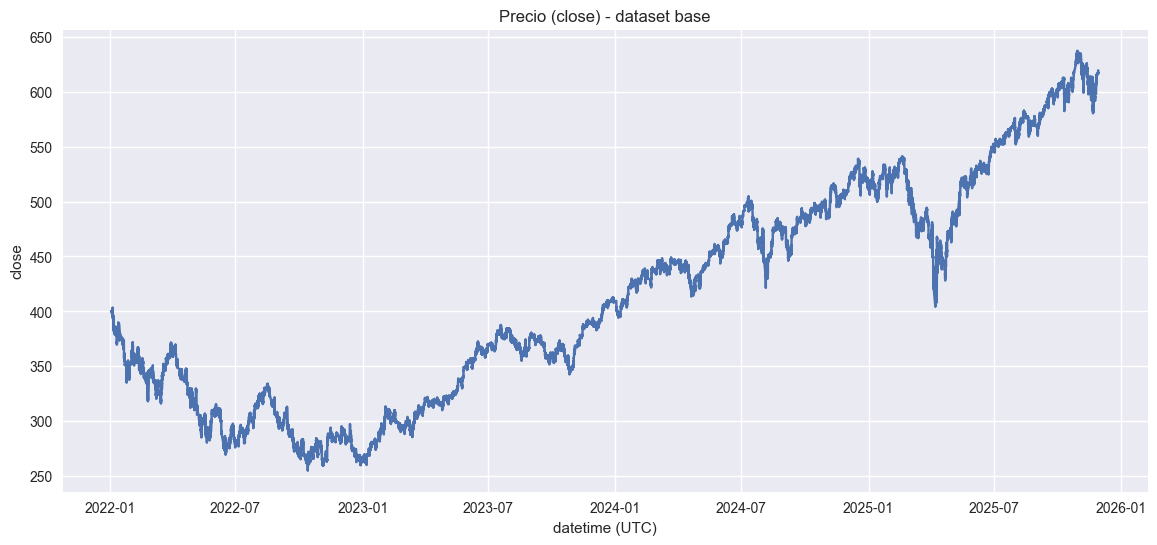

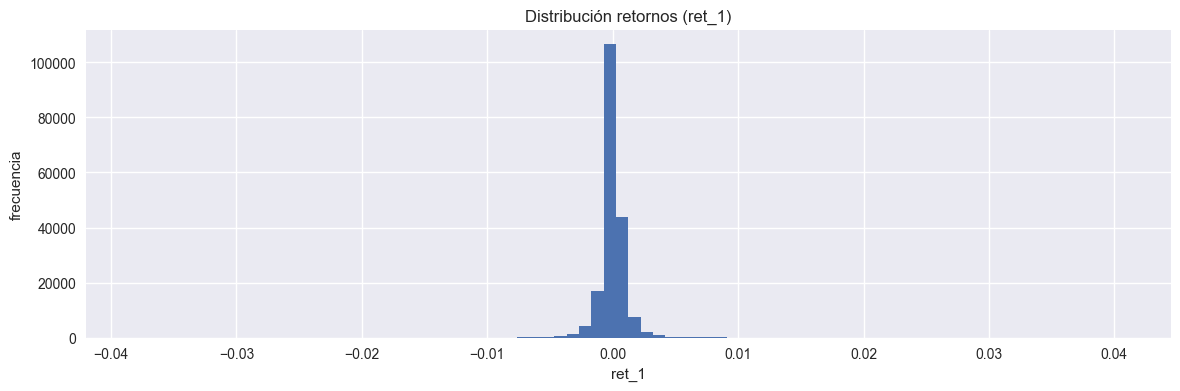

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "datetime" in df.columns, "❌ No existe columna 'datetime' en df"

# 1) Normalizamos nombres a minúsculas para detección robusta (sin perder df original)
df_base = df.copy()
df_base.columns = [c.lower() for c in df_base.columns]

# 2) Detectar columna de precio (close)
price_candidates = ["close", "c", "price", "last", "adj_close", "adj close"]
price_col = None
for c in price_candidates:
    if c in df_base.columns:
        price_col = c
        break

print("✅ Columnas disponibles:", list(df_base.columns))
print("✅ price_col detectada:", price_col)

if price_col is None:
    raise ValueError("❌ No encuentro columna de precio tipo close/c/price/last. Pega df.columns y lo mapeo.")

# 3) Checks temporales
df_base["datetime"] = pd.to_datetime(df_base["datetime"], utc=True, errors="coerce")
df_base = df_base.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates("datetime").reset_index(drop=True)

print("\n--- TIME CHECKS ---")
print("✅ datetime monotónica creciente:", df_base["datetime"].is_monotonic_increasing)
print("✅ rango:", df_base["datetime"].min(), "→", df_base["datetime"].max())
print("✅ duplicados datetime:", df_base["datetime"].duplicated().sum())

# Frecuencia aproximada
if len(df_base) > 5:
    diffs = df_base["datetime"].diff().dropna()
    mode_diff = diffs.mode().iloc[0] if not diffs.mode().empty else diffs.median()
    print("✅ bar size aprox (mode):", mode_diff)

# 4) Limpieza mínima de tipos
df_base[price_col] = pd.to_numeric(df_base[price_col], errors="coerce")
df_base = df_base.dropna(subset=[price_col]).reset_index(drop=True)

print("\n--- VALUE CHECKS ---")
print("✅ n filas:", len(df_base))
print("✅ precio min/mean/max:", df_base[price_col].min(), df_base[price_col].mean(), df_base[price_col].max())
print("✅ NaNs totales:", int(df_base.isna().sum().sum()))

# 5) Features mínimas (sin RSI todavía)
df_base["ret_1"] = df_base[price_col].pct_change()
df_base["logret_1"] = np.log(df_base[price_col]).diff()

# 6) Targets (HORIZON = cuántas velas adelante)
HORIZON = 1  # para 5m: 1=+5min. Luego si quieres lo cambiamos (12=+1h, 78=+1día aprox)
df_base["y_fwd_price"] = df_base[price_col].shift(-HORIZON)
df_base["y_dir"] = (df_base["y_fwd_price"] > df_base[price_col]).astype(int)

# 7) Drop NaNs creados por shift/pct_change
df_base = df_base.dropna(subset=["ret_1", "logret_1", "y_fwd_price"]).reset_index(drop=True)

print("\n--- TARGET CHECKS ---")
print("✅ df_base shape:", df_base.shape)
print("✅ y_dir balance (mean=prob subida):", df_base["y_dir"].mean().round(4))
print("✅ columnas finales:", ["datetime", price_col, "ret_1", "logret_1", "y_fwd_price", "y_dir"])

display(df_base[["datetime", price_col, "ret_1", "logret_1", "y_fwd_price", "y_dir"]].head(5))
display(df_base[["datetime", price_col, "ret_1", "logret_1", "y_fwd_price", "y_dir"]].tail(5))

# 8) Plots rápidos de sanity
plt.figure(figsize=(14,6))
plt.plot(df_base["datetime"], df_base[price_col])
plt.title(f"Precio ({price_col}) - dataset base")
plt.xlabel("datetime (UTC)")
plt.ylabel(price_col)
plt.show()

plt.figure(figsize=(14,4))
plt.hist(df_base["ret_1"].values, bins=80)
plt.title("Distribución retornos (ret_1)")
plt.xlabel("ret_1")
plt.ylabel("frecuencia")
plt.show()


✅ RSI añadido: True
✅ NaNs RSI (esperable al inicio): 14
✅ RSI min/mean/max: 1.7277542401465666 51.04891038952703 96.24067687400357
✅ % fuera de [0,100]: 0.0 %


,datetime,close,rsi_14
0,2022-01-03 09:10:00+00:00,399.53,NaN
1,2022-01-03 09:15:00+00:00,399.35,NaN
2,2022-01-03 09:20:00+00:00,399.49,NaN
3,2022-01-03 09:25:00+00:00,399.40,NaN
4,2022-01-03 09:30:00+00:00,399.34,NaN
5,2022-01-03 09:35:00+00:00,399.43,NaN
6,2022-01-03 09:40:00+00:00,399.44,NaN
7,2022-01-03 09:45:00+00:00,399.54,NaN
8,2022-01-03 09:50:00+00:00,399.63,NaN
9,2022-01-03 09:55:00+00:00,399.76,NaN


,datetime,close,rsi_14
185160,2025-11-28 21:30:00+00:00,619.1000,51.107676
185161,2025-11-28 21:35:00+00:00,619.0800,50.384668
185162,2025-11-28 21:40:00+00:00,619.0796,50.369321
185163,2025-11-28 21:45:00+00:00,619.2100,55.164085
185164,2025-11-28 21:50:00+00:00,619.1700,53.458015


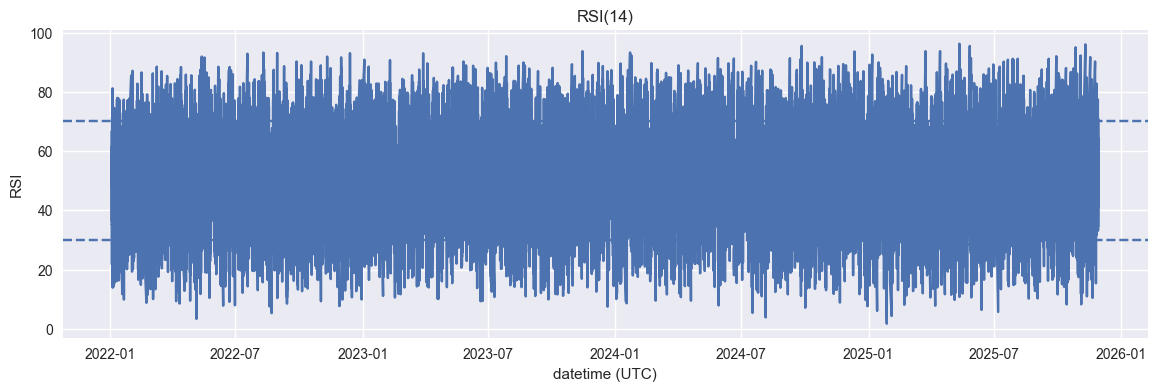

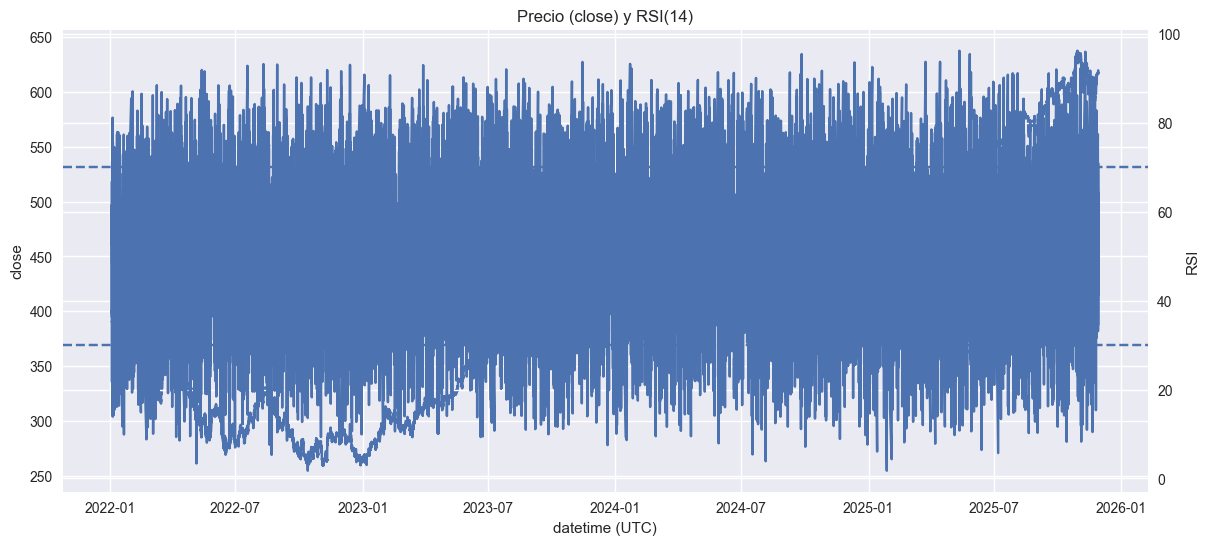

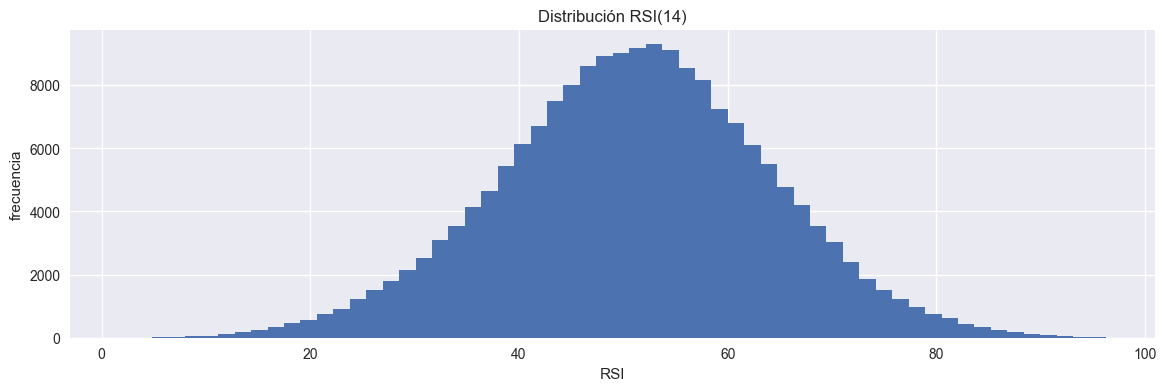

In [4]:
# ===== CELDA 4: RSI (Wilder) como feature + checks =====
import numpy as np
import matplotlib.pyplot as plt

RSI_PERIOD = 14  # estándar

# Aseguramos que existe df_base y price_col (de la celda 3)
assert "df_base" in globals(), "❌ No existe df_base. Ejecuta la Celda 3 primero."
assert "price_col" in globals(), "❌ No existe price_col. Ejecuta la Celda 3 primero."
assert price_col in df_base.columns, f"❌ price_col '{price_col}' no está en df_base.columns"

close = df_base[price_col].astype(float)

# RSI Wilder usando EWM (equivalente al smoothing de Wilder)
delta = close.diff()
gain = delta.clip(lower=0.0)
loss = (-delta).clip(lower=0.0)

alpha = 1.0 / RSI_PERIOD
avg_gain = gain.ewm(alpha=alpha, min_periods=RSI_PERIOD, adjust=False).mean()
avg_loss = loss.ewm(alpha=alpha, min_periods=RSI_PERIOD, adjust=False).mean()

rs = avg_gain / (avg_loss + 1e-12)
rsi = 100.0 - (100.0 / (1.0 + rs))

df_base[f"rsi_{RSI_PERIOD}"] = rsi

# ===== Checks =====
print("✅ RSI añadido:", f"rsi_{RSI_PERIOD}" in df_base.columns)
print("✅ NaNs RSI (esperable al inicio):", int(df_base[f"rsi_{RSI_PERIOD}"].isna().sum()))
print("✅ RSI min/mean/max:",
      float(df_base[f"rsi_{RSI_PERIOD}"].min(skipna=True)),
      float(df_base[f"rsi_{RSI_PERIOD}"].mean(skipna=True)),
      float(df_base[f"rsi_{RSI_PERIOD}"].max(skipna=True)))

# Check de rango lógico
rsi_ok = df_base[f"rsi_{RSI_PERIOD}"].dropna()
print("✅ % fuera de [0,100]:",
      float(((rsi_ok < 0) | (rsi_ok > 100)).mean()) * 100, "%")

display(df_base[["datetime", price_col, f"rsi_{RSI_PERIOD}"]].head(20))
display(df_base[["datetime", price_col, f"rsi_{RSI_PERIOD}"]].tail(5))

# ===== Plots =====
# 1) RSI solo
plt.figure(figsize=(14,4))
plt.plot(df_base["datetime"], df_base[f"rsi_{RSI_PERIOD}"])
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")
plt.title(f"RSI({RSI_PERIOD})")
plt.xlabel("datetime (UTC)")
plt.ylabel("RSI")
plt.show()

# 2) Precio + RSI (twin axis)
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(df_base["datetime"], df_base[price_col])
ax1.set_title(f"Precio ({price_col}) y RSI({RSI_PERIOD})")
ax1.set_xlabel("datetime (UTC)")
ax1.set_ylabel(price_col)

ax2 = ax1.twinx()
ax2.plot(df_base["datetime"], df_base[f"rsi_{RSI_PERIOD}"])
ax2.axhline(70, linestyle="--")
ax2.axhline(30, linestyle="--")
ax2.set_ylabel("RSI")

plt.show()

# 3) Histograma RSI (para ver distribución)
plt.figure(figsize=(14,4))
plt.hist(rsi_ok.values, bins=60)
plt.title(f"Distribución RSI({RSI_PERIOD})")
plt.xlabel("RSI")
plt.ylabel("frecuencia")
plt.show()


In [5]:
# ===== CELDA: DATA + TARGET (VOL-TARGET) + SCALING + WINDOWS (NO LEAKAGE) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
HORIZON = 12
WINDOW  = 64
VOL_WIN = 64
RSI_PERIOD = 14

TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10

EPS = 1e-8

# vol floor y clipping del target
VOL_FLOOR_Q = 0.01
CLIP_Q_LOW  = 0.001
CLIP_Q_HIGH = 0.999

# ---------------- CHECKS ----------------
assert "df_base" in globals(), "❌ No existe df_base. Ejecuta la celda anterior donde cargas/preprocesas."
assert "price_col" in globals(), "❌ No existe price_col."
assert "datetime" in df_base.columns, "❌ df_base debe tener columna 'datetime'."
assert price_col in df_base.columns, f"❌ price_col='{price_col}' no está en df_base"

# ---------------- BASE DF ----------------
df4 = df_base.copy()
df4["datetime"] = pd.to_datetime(df4["datetime"], utc=True)
df4 = df4.sort_values("datetime").reset_index(drop=True)

close = df4[price_col].astype(float)

# ---------------- FEATURES MIN (como llevas tú) ----------------
# ret_1 / logret_1
if "ret_1" not in df4.columns:
    df4["ret_1"] = close.pct_change()

if "logret_1" not in df4.columns:
    df4["logret_1"] = np.log((close + EPS) / (close.shift(1) + EPS))

# volume_norm
if "volume_norm" not in df4.columns and "volume" in df4.columns:
    v = df4["volume"].astype(float)
    df4["volume_norm"] = (v - v.rolling(64).mean()) / (v.rolling(64).std() + EPS)

# RSI Wilder
rsi_col = f"rsi_{RSI_PERIOD}"
if rsi_col not in df4.columns:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1/RSI_PERIOD, adjust=False, min_periods=RSI_PERIOD).mean()
    avg_loss = loss.ewm(alpha=1/RSI_PERIOD, adjust=False, min_periods=RSI_PERIOD).mean()
    rs = avg_gain / (avg_loss + EPS)
    df4[rsi_col] = 100.0 - (100.0 / (1.0 + rs))

# volumen extra
if "log_vol" not in df4.columns and "volume" in df4.columns:
    df4["log_vol"] = np.log1p(df4["volume"].astype(float))

# vwap dev
if "vwap_dev" not in df4.columns and "vwap" in df4.columns:
    df4["vwap_dev"] = (df4["vwap"].astype(float) / close) - 1.0

# volatilidad rolling (para vol-target)
vol_col = f"vol_{VOL_WIN}"
df4[vol_col] = df4["logret_1"].rolling(VOL_WIN).std()

# ---------------- TARGETS ----------------
# ⚠️ CLAVE: no cruzar el market close.
# En vez de close.shift(-HORIZON) global, hacemos shift *dentro de cada sesión (día NY)*.
_dt_ny = df4["datetime"].dt.tz_convert("America/New_York")
_sess = _dt_ny.dt.date

df4["close_fwd"] = close.groupby(_sess).shift(-HORIZON)
df4["y_fwd_logret"] = np.log((df4["close_fwd"] + EPS) / (close + EPS))
df4["y_dir"] = (df4["y_fwd_logret"] > 0).astype(int)

n_cross = int(df4["close_fwd"].isna().sum())
print(f"⚙️ Targets: descartadas {n_cross} filas por cruce de sesión (no hay +H velas en el día).")

# features usadas
candidate_features = ["ret_1", "logret_1", rsi_col, "volume_norm", "log_vol", "vwap_dev"]
feature_cols = [c for c in candidate_features if c in df4.columns]

print("✅ HORIZON:", HORIZON, "| WINDOW:", WINDOW)
print("✅ Features usadas:", feature_cols)
print("✅ Target interno: y_vt = y_fwd_logret / vol")

# ---------------- MODEL DF (drop NaNs) ----------------
keep_cols = ["datetime", price_col, "close_fwd", "y_fwd_logret", "y_dir", vol_col] + feature_cols
df_model = df4[keep_cols].dropna().reset_index(drop=True)

# ---------------- SPLITS (purged simple) ----------------
N = len(df_model)
n_train = int(N * TRAIN_FRAC)
n_val   = int(N * VAL_FRAC)

df_train = df_model.iloc[:n_train].copy()
df_val   = df_model.iloc[n_train:n_train+n_val].copy()
df_test  = df_model.iloc[n_train+n_val:].copy()

print("\n--- SPLITS (purged) ---")
print("Train:", df_train.shape, "|", df_train["datetime"].min(), "→", df_train["datetime"].max())
print("Val  :", df_val.shape,   "|", df_val["datetime"].min(),   "→", df_val["datetime"].max())
print("Test :", df_test.shape,  "|", df_test["datetime"].min(),  "→", df_test["datetime"].max())

# ---------------- VOL-FLOOR + VOL-TARGET ----------------
vol_floor = float(df_train[vol_col].quantile(VOL_FLOOR_Q))
print(f"\n✅ vol_floor (train q={VOL_FLOOR_Q:.2f}): {vol_floor:.6g}")

def make_y_vt_and_vol(dfx):
    vol_used = np.maximum(dfx[vol_col].astype(float).values, vol_floor).astype(np.float32)
    y_vt = (dfx["y_fwd_logret"].astype(float).values / (vol_used + EPS)).astype(np.float32)
    return y_vt, vol_used

ytr_vt, vtr = make_y_vt_and_vol(df_train)
yva_vt, vva = make_y_vt_and_vol(df_val)
yte_vt, vte = make_y_vt_and_vol(df_test)

# winsorize (train bounds)
lo = float(np.quantile(ytr_vt, CLIP_Q_LOW))
hi = float(np.quantile(ytr_vt, CLIP_Q_HIGH))
print(f"✅ target clip bounds (train): ({lo}, {hi})")

ytr_vt = np.clip(ytr_vt, lo, hi)
yva_vt = np.clip(yva_vt, lo, hi)
yte_vt = np.clip(yte_vt, lo, hi)

# dejamos bounds con nombre explícito (útil para calibración)
y_clip_lo, y_clip_hi = lo, hi

# ---------------- SCALING ----------------
from sklearn.preprocessing import StandardScaler
x_scaler = StandardScaler()
y_scaler = StandardScaler()

Xtr = df_train[feature_cols].astype(float).values
Xva = df_val[feature_cols].astype(float).values
Xte = df_test[feature_cols].astype(float).values

Xtr_s = x_scaler.fit_transform(Xtr)
Xva_s = x_scaler.transform(Xva)
Xte_s = x_scaler.transform(Xte)

ytr_s = y_scaler.fit_transform(ytr_vt.reshape(-1,1)).reshape(-1)
yva_s = y_scaler.transform(yva_vt.reshape(-1,1)).reshape(-1)
yte_s = y_scaler.transform(yte_vt.reshape(-1,1)).reshape(-1)

y_mean = float(y_scaler.mean_[0])
y_std  = float(y_scaler.scale_[0])
print("\n--- SCALER CHECKS ---")
print("✅ y_mean:", y_mean, "| y_std:", y_std)

# ---------------- WINDOWING ----------------
def make_windows(X, y, window):
    Xw, yw = [], []
    for i in range(window-1, len(X)):
        Xw.append(X[i-window+1:i+1])
        yw.append(y[i])
    return np.asarray(Xw, dtype=np.float32), np.asarray(yw, dtype=np.float32)

X_train, y_train = make_windows(Xtr_s, ytr_s, WINDOW)
X_val,   y_val   = make_windows(Xva_s, yva_s, WINDOW)
X_test,  y_test  = make_windows(Xte_s, yte_s, WINDOW)

# alineamos arrays auxiliares (datetime/close/close_fwd/vol_used) al windowing
def align_aux(dfx, vol_used, window):
    d = dfx.iloc[window-1:].reset_index(drop=True)
    v = vol_used[window-1:]
    return d, v

df_train_w, vtr_w = align_aux(df_train, vtr, WINDOW)
df_val_w,   vva_w = align_aux(df_val,   vva, WINDOW)
df_test_w,  vte_w = align_aux(df_test,  vte, WINDOW)

# guardamos para evaluación
dates_train = df_train_w["datetime"].values
dates_val   = df_val_w["datetime"].values
dates_test  = df_test_w["datetime"].values

close_train = df_train_w[price_col].astype(float).values
close_val   = df_val_w[price_col].astype(float).values
close_test  = df_test_w[price_col].astype(float).values

closef_train = df_train_w["close_fwd"].astype(float).values
closef_val   = df_val_w["close_fwd"].astype(float).values
closef_test  = df_test_w["close_fwd"].astype(float).values

vol_used_train = vtr_w.astype(float)
vol_used_val   = vva_w.astype(float)
vol_used_test  = vte_w.astype(float)

y_val_dir  = df_val_w["y_dir"].astype(int).values
y_test_dir = df_test_w["y_dir"].astype(int).values

print("\n--- WINDOWED SHAPES ---")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

print("\n--- y_scaled sanity ---")
print("train y mean/std:", float(np.mean(y_train)), float(np.std(y_train)))
print("val   y mean/std:", float(np.mean(y_val)),   float(np.std(y_val)))
print("test  y mean/std:", float(np.mean(y_test)),  float(np.std(y_test)))


⚙️ Targets: descartadas 11772 filas por cruce de sesión (no hay +H velas en el día).
✅ HORIZON: 12 | WINDOW: 64
✅ Features usadas: ['ret_1', 'logret_1', 'rsi_14', 'volume_norm', 'log_vol', 'vwap_dev']
✅ Target interno: y_vt = y_fwd_logret / vol

--- SPLITS (purged) ---
Train: (138664, 12) | 2022-01-03 14:25:00+00:00 → 2025-02-24 14:45:00+00:00
Val  : (17333, 12) | 2025-02-24 14:50:00+00:00 → 2025-07-15 10:25:00+00:00
Test : (17333, 12) | 2025-07-15 10:30:00+00:00 → 2025-11-28 20:50:00+00:00

✅ vol_floor (train q=0.01): 0.000232214
✅ target clip bounds (train): (-28.590633392333984, 23.21552848815918)

--- SCALER CHECKS ---
✅ y_mean: -0.01635100015301595 | y_std: 4.074897853735893

--- WINDOWED SHAPES ---
X_train: (138601, 64, 6) y_train: (138601,)
X_val  : (17270, 64, 6) y_val  : (17270,)
X_test : (17270, 64, 6) y_test : (17270,)

--- y_scaled sanity ---
train y mean/std: -0.00011601599544519559 1.0001492500305176
val   y mean/std: 0.0052115037105977535 0.965917706489563
test  y mean/s

In [6]:
# ===== CELDA 6: PyTorch Dataset + DataLoader + sanity checks =====
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd

assert "device" in globals(), "❌ No existe device. Ejecuta Celda 1."
for v in ["X_train","y_train","X_val","y_val","X_test","y_test","dates_train","dates_val","dates_test"]:
    assert v in globals(), f"❌ No existe {v}. Ejecuta Celda 5."

# y_dir (si no existe, lo creamos desde df_*_w["y_dir"])
if "y_train_dir" not in globals():
    assert "df_train_w" in globals() and "y_dir" in df_train_w.columns, "❌ No existe y_train_dir ni df_train_w['y_dir']."
    y_train_dir = df_train_w["y_dir"].astype(int).values
if "y_val_dir" not in globals():
    assert "df_val_w" in globals() and "y_dir" in df_val_w.columns, "❌ No existe y_val_dir ni df_val_w['y_dir']."
    y_val_dir = df_val_w["y_dir"].astype(int).values
if "y_test_dir" not in globals():
    assert "df_test_w" in globals() and "y_dir" in df_test_w.columns, "❌ No existe y_test_dir ni df_test_w['y_dir']."
    y_test_dir = df_test_w["y_dir"].astype(int).values

print("✅ device:", device)

# --- Config loader ---
BATCH_SIZE = 256   # en CPU suele ir bien. Si va lento, baja a 128 o 64.
NUM_WORKERS = 0    # Windows + notebooks: 0 es lo más estable
PIN_MEMORY = False # CPU -> False

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, T, F) float32
        # y: (N,) float32
        assert isinstance(X, np.ndarray) and isinstance(y, np.ndarray)
        assert X.ndim == 3, f"X debe ser 3D (N,T,F). Got {X.shape}"
        assert y.ndim == 1, f"y debe ser 1D (N,). Got {y.shape}"
        assert len(X) == len(y), "X e y deben tener misma longitud"

        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):

        
        return self.X[idx], self.y[idx]

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds   = TimeSeriesDataset(X_val, y_val)
test_ds  = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)

print("\n--- DATASET SIZES ---")
print("train:", len(train_ds), "| val:", len(val_ds), "| test:", len(test_ds))

# --- Batch sanity ---
xb, yb = next(iter(train_loader))
print("\n--- BATCH SANITY ---")
print("xb shape:", tuple(xb.shape), "| dtype:", xb.dtype)
print("yb shape:", tuple(yb.shape), "| dtype:", yb.dtype)

# Mover a device (aquí ya comprobamos que todo va ok)
xb_dev = xb.to(device)
yb_dev = yb.to(device)
print("moved to device -> xb:", xb_dev.device, "yb:", yb_dev.device)

# --- Stats útiles ---
print("\n--- y (scaled) stats ---")
print("train y: mean", float(torch.mean(train_ds.y)), "std", float(torch.std(train_ds.y)))
print("val   y: mean", float(torch.mean(val_ds.y)),   "std", float(torch.std(val_ds.y)))
print("test  y: mean", float(torch.mean(test_ds.y)),  "std", float(torch.std(test_ds.y)))

# --- Checks direccionales (ventaneados) ---
# (los y_dir_* ya están alineados con y_*)
assert len(y_train_dir) == len(y_train), "❌ y_train_dir no está alineado con y_train"
assert len(y_val_dir) == len(y_val), "❌ y_val_dir no está alineado con y_val"
assert len(y_test_dir) == len(y_test), "❌ y_test_dir no está alineado con y_test"

print("\n--- y_dir balance (windowed) ---")
print("train y_dir mean:", float(np.mean(y_train_dir)))
print("val   y_dir mean:", float(np.mean(y_val_dir)))
print("test  y_dir mean:", float(np.mean(y_test_dir)))

# --- Mini-check: primer sample (solo para confirmar que hay señal) ---
print("\n--- FIRST SAMPLE CHECK ---")
print("X_train[0] (first timestep, first 5 features):", X_train[0, 0, :5])
print("y_train[0] (scaled):", y_train[0], "| y_dir:", y_train_dir[0], "| date:", pd.to_datetime(dates_train[0]))


✅ device: cpu

--- DATASET SIZES ---
train: 138601 | val: 17270 | test: 17270

--- BATCH SANITY ---
xb shape: (256, 64, 6) | dtype: torch.float32
yb shape: (256,) | dtype: torch.float32
moved to device -> xb: cpu yb: cpu

--- y (scaled) stats ---
train y: mean -0.0001160152824013494 std 1.0001529455184937
val   y: mean 0.005211502313613892 std 0.9659457206726074
test  y: mean -0.007978598587214947 std 0.9775896072387695

--- y_dir balance (windowed) ---
train y_dir mean: 0.511763984386837
val   y_dir mean: 0.5099015634047481
test  y_dir mean: 0.5342790966994788

--- FIRST SAMPLE CHECK ---
X_train[0] (first timestep, first 5 features): [-0.6214093  -0.62067586 -1.5981665  -0.5253828  -0.04201884]
y_train[0] (scaled): -0.3206944 | y_dir: 0 | date: 2022-01-03 19:40:00


In [7]:
# ===== CELDA 7 (REEMPLAZO): Modelo con la mejor config del grid (layers=2 para que dropout cuente) =====
import torch
import torch.nn as nn

N_FEATURES = X_train.shape[-1]

HIDDEN = 32
NUM_LAYERS = 2
DROPOUT = 0.2
USE_SKIP = True

class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=32, num_layers=2, dropout=0.2, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0),  # <- aquí sí aplica
        )

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 1),
        )

        if use_skip:
            self.skip = nn.Linear(n_features, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        h_last = h_n[-1]  # (B, hidden)
        y_hat = self.head(h_last).squeeze(-1)
        if self.use_skip:
            y_hat = y_hat + self.skip(x[:, -1, :]).squeeze(-1)
        return y_hat

model = LSTMRegressor(
    n_features=N_FEATURES,
    hidden_size=HIDDEN,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    use_skip=USE_SKIP
).to(device)

print("✅ Model:", model.__class__.__name__)
print("✅ n_features:", N_FEATURES)
print("✅ hidden/layers/dropout:", HIDDEN, NUM_LAYERS, DROPOUT)
print("✅ device:", device)

# forward sanity
xb, yb = next(iter(train_loader))
xb = xb.to(device)
with torch.no_grad():
    pred = model(xb)
print("pred stats:", float(pred.mean()), float(pred.std()), float(pred.min()), float(pred.max()))


✅ Model: LSTMRegressor
✅ n_features: 6
✅ hidden/layers/dropout: 32 2 0.2
✅ device: cpu
pred stats: -0.25877735018730164 0.7446691989898682 -1.6955102682113647 3.186704635620117


🚀 Training start
device=cpu | epochs=25 | lr=0.001 | wd=1e-05 | clip=1.0
early_stop: patience=6, min_delta=0.0001
Epoch 01 | train_loss=0.465835 val_loss=0.431515 | train_mae=0.66114 val_mae=0.62296 | lr=1.00e-03 | ✅ best (21.0s)
Epoch 02 | train_loss=0.453660 val_loss=0.430864 | train_mae=0.64650 val_mae=0.62212 | lr=1.00e-03 | ✅ best (25.8s)
Epoch 03 | train_loss=0.452656 val_loss=0.429848 | train_mae=0.64521 val_mae=0.62072 | lr=1.00e-03 | ✅ best (16.6s)
Epoch 04 | train_loss=0.452283 val_loss=0.430458 | train_mae=0.64479 val_mae=0.62133 | lr=1.00e-03 |  (16.2s)
Epoch 05 | train_loss=0.451952 val_loss=0.429701 | train_mae=0.64436 val_mae=0.62027 | lr=1.00e-03 | ✅ best (17.2s)
Epoch 06 | train_loss=0.451611 val_loss=0.429189 | train_mae=0.64388 val_mae=0.61982 | lr=1.00e-03 | ✅ best (16.0s)
Epoch 07 | train_loss=0.451441 val_loss=0.429257 | train_mae=0.64373 val_mae=0.61989 | lr=1.00e-03 |  (16.3s)
Epoch 08 | train_loss=0.451104 val_loss=0.430427 | train_mae=0.64341 val_mae=0.62154 |

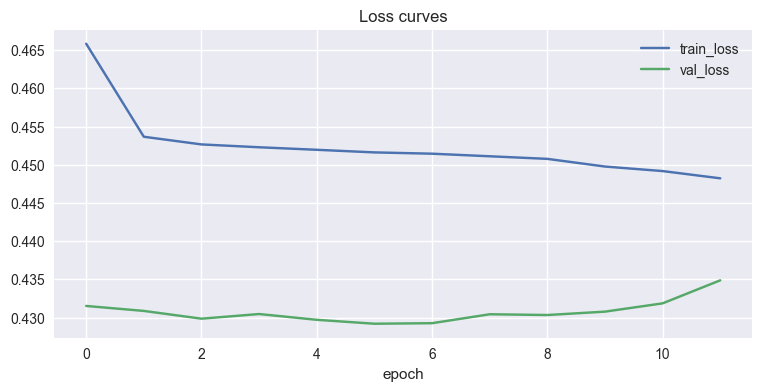

In [8]:
# ===== CELDA 8 (REEMPLAZO): Training loop completo (PyTorch) con Huber =====
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import inspect
import numpy as np

# ---------- CONFIG ----------
EPOCHS = 25
LR = 1e-3
WEIGHT_DECAY = 1e-5
CLIP_NORM = 1.0

PATIENCE = 6
MIN_DELTA = 1e-4
MODEL_PATH = "best_lstm_qqq.pt"

# loss: Huber (SmoothL1) para outliers + estabilidad
criterion = nn.SmoothL1Loss(beta=0.5)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ReduceLROnPlateau compatible con versiones que no soportan verbose
sched_kwargs = dict(optimizer=optimizer, mode="min", factor=0.5, patience=2, min_lr=1e-6)
sig = inspect.signature(torch.optim.lr_scheduler.ReduceLROnPlateau.__init__)
if "verbose" in sig.parameters:
    sched_kwargs["verbose"] = True
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(**sched_kwargs)

class EarlyStopping:
    def __init__(self, patience=6, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.counter = 0
        self.best_epoch = -1

    def step(self, metric, epoch):
        improved = (self.best - metric) > self.min_delta
        if improved:
            self.best = metric
            self.counter = 0
            self.best_epoch = epoch
            return True
        self.counter += 1
        return False

    def should_stop(self):
        return self.counter >= self.patience

def run_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    losses = []
    maes = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        pred = model(xb)
        loss = criterion(pred, yb)

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
            optimizer.step()

        with torch.no_grad():
            mae = torch.mean(torch.abs(pred - yb))

        losses.append(loss.detach().cpu().item())
        maes.append(mae.detach().cpu().item())

    return float(np.mean(losses)), float(np.mean(maes))

print("🚀 Training start")
print(f"device={device} | epochs={EPOCHS} | lr={LR} | wd={WEIGHT_DECAY} | clip={CLIP_NORM}")
print(f"early_stop: patience={PATIENCE}, min_delta={MIN_DELTA}")

early = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)

history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": [], "lr": []}
best_state = None

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    ep0 = time.time()

    tr_loss, tr_mae = run_epoch(model, train_loader, train=True)
    va_loss, va_mae = run_epoch(model, val_loader, train=False)

    scheduler.step(va_loss)
    lr_now = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_mae"].append(tr_mae)
    history["val_mae"].append(va_mae)
    history["lr"].append(lr_now)

    is_best = early.step(va_loss, epoch)
    if is_best:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), MODEL_PATH)

    flag = "✅ best" if is_best else ""
    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.6f} val_loss={va_loss:.6f} | "
          f"train_mae={tr_mae:.5f} val_mae={va_mae:.5f} | lr={lr_now:.2e} | {flag} ({time.time()-ep0:.1f}s)")

    if early.should_stop():
        print(f"\n🛑 EarlyStopping: sin mejora suficiente en {PATIENCE} epochs.")
        break

print(f"\n⏱️ Total time: {time.time()-t0:.1f}s")
print(f"🏆 Best val_loss: {early.best:.6f} at epoch {early.best_epoch}")

# cargar best
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
print("✅ Best model cargado desde:", MODEL_PATH)

# plot losses
plt.figure(figsize=(9,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss curves")
plt.xlabel("epoch")
plt.legend()
plt.show()


In [9]:
# ===== CELDA 8B (NUEVA): Mini grid search rápido (CPU-friendly) =====
import numpy as np
import torch
import torch.nn as nn
from itertools import product

# SUBSAMPLE para que no tarde la vida (ajusta si quieres)
MAX_TRAIN = 60000
MAX_VAL   = 12000

Xtr_s = X_train[-MAX_TRAIN:]
ytr_s = y_train[-MAX_TRAIN:]
Xva_s = X_val[:MAX_VAL]
yva_s = y_val[:MAX_VAL]

from torch.utils.data import Dataset, DataLoader

class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_loaders(Xtr, ytr, Xva, yva, bs=512):
    tr = DataLoader(TSDataset(Xtr, ytr), batch_size=bs, shuffle=True, num_workers=0)
    va = DataLoader(TSDataset(Xva, yva), batch_size=bs, shuffle=False, num_workers=0)
    return tr, va

def train_quick(cfg, train_loader_s, val_loader_s, n_features, device):
    class SmallLSTM(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(
                input_size=n_features,
                hidden_size=cfg["hidden"],
                num_layers=cfg["layers"],
                dropout=cfg["dropout"] if cfg["layers"] > 1 else 0.0,
                batch_first=True,
            )
            self.fc = nn.Linear(cfg["hidden"], 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :]).squeeze(-1)

    model = SmallLSTM().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])
    loss_fn = nn.HuberLoss()

    best = float("inf")
    bad = 0

    for epoch in range(cfg["epochs"]):
        model.train()
        for xb, yb in train_loader_s:
            xb = xb.to(device); yb = yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

        model.eval()
        vlosses = []
        with torch.no_grad():
            for xb, yb in val_loader_s:
                xb = xb.to(device); yb = yb.to(device)
                pred = model(xb)
                vlosses.append(loss_fn(pred, yb).item())
        v = float(np.mean(vlosses))
        if v < best - 1e-6:
            best = v
            bad = 0
        else:
            bad += 1
            if bad >= cfg["patience"]:
                break
    return best

train_loader_s, val_loader_s = make_loaders(Xtr_s, ytr_s, Xva_s, yva_s, bs=512)

grid = {
    "hidden":  [32, 64],
    "layers":  [1, 2],
    "dropout": [0.0, 0.2, 0.4],
    "lr":      [3e-4, 1e-3],
    "wd":      [0.0, 1e-5, 1e-4],
}

base_cfg = {"epochs": 8, "patience": 2}
MAX_COMBOS = 24  # limita combinaciones para que sea rápido (y evitas KeyboardInterrupt)


keys = list(grid.keys())
best_cfg = None
best_val = float("inf")
results = []

try:
    for j, values in enumerate(product(*[grid[k] for k in keys]), start=1):
        if j > MAX_COMBOS:
            print(f"\n⏹️ Paro en MAX_COMBOS={MAX_COMBOS} (puedes subirlo si quieres)")
            break
        cfg = dict(zip(keys, values)) | base_cfg
        v = train_quick(cfg, train_loader_s, val_loader_s, n_features=X_train.shape[-1], device=device)
        results.append((v, cfg))
        print("val_loss:", round(v, 6), "|", cfg)
except KeyboardInterrupt:
    print("\n⏹️ Interrumpido por el usuario. Mostrando resultados parciales...")

results.sort(key=lambda x: x[0])
print("\n🏆 TOP 5 configs:")
for v, cfg in results[:5]:
    print(round(v, 6), cfg)


val_loss: 0.342322 | {'hidden': 32, 'layers': 1, 'dropout': 0.0, 'lr': 0.0003, 'wd': 0.0, 'epochs': 8, 'patience': 2}
val_loss: 0.342276 | {'hidden': 32, 'layers': 1, 'dropout': 0.0, 'lr': 0.0003, 'wd': 1e-05, 'epochs': 8, 'patience': 2}
val_loss: 0.342201 | {'hidden': 32, 'layers': 1, 'dropout': 0.0, 'lr': 0.0003, 'wd': 0.0001, 'epochs': 8, 'patience': 2}
val_loss: 0.343032 | {'hidden': 32, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'wd': 0.0, 'epochs': 8, 'patience': 2}
val_loss: 0.342544 | {'hidden': 32, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'wd': 1e-05, 'epochs': 8, 'patience': 2}
val_loss: 0.342693 | {'hidden': 32, 'layers': 1, 'dropout': 0.0, 'lr': 0.001, 'wd': 0.0001, 'epochs': 8, 'patience': 2}
val_loss: 0.342306 | {'hidden': 32, 'layers': 1, 'dropout': 0.2, 'lr': 0.0003, 'wd': 0.0, 'epochs': 8, 'patience': 2}
val_loss: 0.342361 | {'hidden': 32, 'layers': 1, 'dropout': 0.2, 'lr': 0.0003, 'wd': 1e-05, 'epochs': 8, 'patience': 2}
val_loss: 0.342208 | {'hidden': 32, 'layers': 1

In [10]:
# ===== CELDA 13 (REEMPLAZAR ENTERA): Diagnóstico rápido + predict_scaled ÚNICA =====
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score

@torch.no_grad()
def predict_scaled(model, data, device, batch_size=2048):
    """
    Devuelve predicciones en escala (scaled).
    data puede ser:
      - DataLoader (yield xb, yb)  -> recomendado (val/test con shuffle=False)
      - np.ndarray X con shape (N, T, F)
    """
    model.eval()
    preds = []

    # Caso 1: numpy array
    if isinstance(data, np.ndarray):
        X_np = data
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
            pb = model(xb).detach().cpu().numpy()
            preds.append(pb.reshape(-1))
        return np.concatenate(preds, axis=0)

    # Caso 2: DataLoader / iterable de batches
    for batch in data:
        xb = batch[0]              # soporta (xb, yb) o (xb, yb, ...)
        xb = xb.to(device)
        pb = model(xb).detach().cpu().numpy()
        preds.append(pb.reshape(-1))

    return np.concatenate(preds, axis=0)

def summarize(name, y_true, y_dir, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    # AUC con score continuo (si y_pred tiene varianza ~0, AUC~0.5)
    auc = roc_auc_score(y_dir.astype(int), y_pred)

    print(f"\n--- {name} ---")
    print(f"MSE={mse:.6f} | MAE={mae:.6f} | AUC={auc:.3f}")
    print("pred mean/std:", float(y_pred.mean()), float(y_pred.std()))
    print("true mean/std:", float(y_true.mean()), float(y_true.std()))
    print("pred min/max:", float(y_pred.min()), float(y_pred.max()))
    print("true min/max:", float(y_true.min()), float(y_true.max()))

# Baseline pred=0 en escala
val_pred0  = np.zeros_like(y_val)
test_pred0 = np.zeros_like(y_test)

print("✅ BASELINE pred=0 (scaled)")
print("VAL  MSE0:", mean_squared_error(y_val, val_pred0))
print("TEST MSE0:", mean_squared_error(y_test, test_pred0))

# Predicciones del modelo (usa loaders si los tienes; si no, usa X_val/X_test)
use_loaders = ("val_loader" in globals()) and ("test_loader" in globals())

if use_loaders:
    val_pred  = predict_scaled(model, val_loader, device)
    test_pred = predict_scaled(model, test_loader, device)
else:
    val_pred  = predict_scaled(model, X_val, device)
    test_pred = predict_scaled(model, X_test, device)

# Sanity de longitudes
print("\n--- LENGTH CHECKS ---")
print("len(y_val) :", len(y_val),  "| len(pred_val) :", len(val_pred))
print("len(y_test):", len(y_test), "| len(pred_test):", len(test_pred))
assert len(val_pred)  == len(y_val),  "❌ pred_val no alinea con y_val (revisa drop_last/shuffle)"
assert len(test_pred) == len(y_test), "❌ pred_test no alinea con y_test (revisa drop_last/shuffle)"

summarize("VAL",  y_val,  y_val_dir,  val_pred)
summarize("TEST", y_test, y_test_dir, test_pred)

# ✅ Dejamos estas variables listas para la siguiente celda (evita recomputar)
pred_val_scaled  = val_pred.reshape(-1)
pred_test_scaled = test_pred.reshape(-1)

print("\n✅ Variables listas:")
print("   pred_val_scaled, pred_test_scaled")


✅ BASELINE pred=0 (scaled)
VAL  MSE0: 0.9330242276191711
TEST MSE0: 0.9556897282600403

--- LENGTH CHECKS ---
len(y_val) : 17270 | len(pred_val) : 17270
len(y_test): 17270 | len(pred_test): 17270

--- VAL ---
MSE=0.935363 | MAE=0.622218 | AUC=0.524
pred mean/std: 0.02782769314944744 0.054151423275470734
true mean/std: 0.0052115037105977535 0.965917706489563
pred min/max: -0.6268088817596436 1.2706469297409058
true min/max: -7.012269496917725 5.7012176513671875

--- TEST ---
MSE=0.959035 | MAE=0.612741 | AUC=0.516
pred mean/std: 0.02489268220961094 0.05205513909459114
true mean/std: -0.007978597655892372 0.977561354637146
pred min/max: -0.48771846294403076 0.6233021020889282
true min/max: -7.012269496917725 5.7012176513671875

✅ Variables listas:
   pred_val_scaled, pred_test_scaled


✅ Backtest inputs OK
timeframe: 5m | hold: 2h -> H=24 velas
Ventana entradas (Madrid): 13:45 - 18:00
Año: 2025
Rows usadas (2025): 40700 | rango: 2024-12-31 23:05:00+00:00 → 2025-11-28 20:50:00+00:00
noise_std (VAL, logret): 0.00450133
thr: 0.0 (THR_SIGMA=0.0)

=== SIN RUIDO ===
Equity final: 1.231
Total return: 23.1 %
Sharpe anual (daily): 1.39
Max Drawdown: -6.79 %
N trades: 680

=== CON RUIDO ===
Equity final: 0.8973
Total return: -10.27 %
Sharpe anual (daily): -0.299
Max Drawdown: -20.42 %
N trades: 680


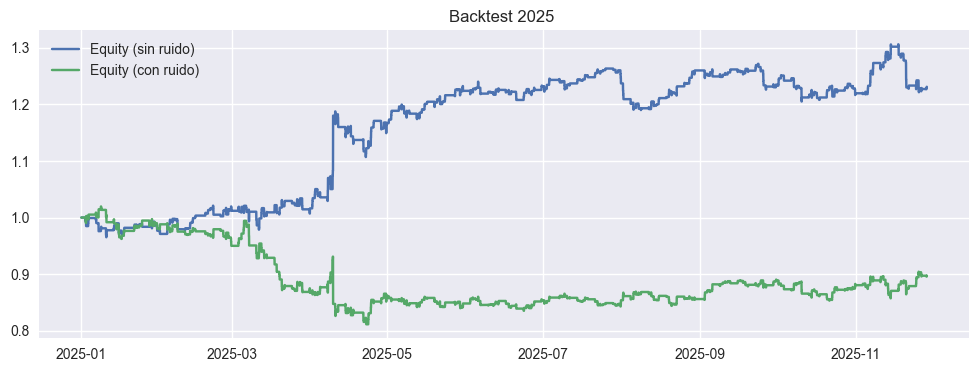

In [11]:
# ===== BACKTEST 2025 (2h fijo, sin solape, entradas 13:45-18:00 Madrid) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- PARAMS ----------------
TIMEFRAME_MIN = 5
HOLD_HOURS = 2
H = int((HOLD_HOURS * 60) // TIMEFRAME_MIN)  # 24 velas de 5m = 2h

YEAR = 2025
ENTRY_START = (13, 45)  # Madrid
ENTRY_END   = (18,  0)  # Madrid

THR_SIGMA = 0.0
COST_BPS_SIDE = 0.0
SEED = 123

# ---------------- CHECKS ----------------
required = [
    "model", "device", "predict_scaled",
    "y_mean", "y_std",
    "X_train", "X_val", "X_test",
    "y_val", "vtr_w", "vva_w", "vte_w",
    "df_train_w", "df_val_w", "df_test_w",
    "price_col"
]
for v in required:
    assert v in globals(), f"❌ Falta {v}. Ejecuta las celdas anteriores."

def vt_scaled_to_logret(arr_scaled: np.ndarray, vol_used: np.ndarray, y_mean: float, y_std: float) -> np.ndarray:
    arr_scaled = np.asarray(arr_scaled, dtype=float).reshape(-1)
    vol_used   = np.asarray(vol_used, dtype=float).reshape(-1)
    arr_vt = arr_scaled * float(y_std) + float(y_mean)
    return arr_vt * vol_used

# ---------- noise_std (VAL) en espacio LOGRET ----------
# Nota: train_loader tiene shuffle=True (no sirve para predecir ordenado) :contentReference[oaicite:3]{index=3}
# Usamos val_loader si existe (shuffle=False) o X_val si no.
if "val_loader" in globals():
    pred_val_scaled = predict_scaled(model, val_loader, device)
else:
    pred_val_scaled = predict_scaled(model, X_val, device)

true_val_logret = vt_scaled_to_logret(y_val, vva_w, y_mean, y_std)
pred_val_logret = vt_scaled_to_logret(pred_val_scaled, vva_w, y_mean, y_std)

resid_val = true_val_logret - pred_val_logret
noise_std = float(np.nanstd(resid_val))
thr = float(THR_SIGMA * noise_std)

# ---------- construir dataframe de backtest para TODO 2025 (train+val+test) ----------
def make_bt_df(df_w: pd.DataFrame, X: np.ndarray, vol_used: np.ndarray) -> pd.DataFrame:
    dt = pd.to_datetime(df_w["datetime"])
    dt_m = dt.dt.tz_convert("Europe/Madrid")
    mask = (dt_m.dt.year == YEAR)

    if int(mask.sum()) == 0:
        return pd.DataFrame(columns=["datetime", "close", "pred_logret"])

    df_sub = df_w.loc[mask, ["datetime", price_col]].copy().reset_index(drop=True)
    X_sub = X[mask.values]
    vol_sub = np.asarray(vol_used)[mask.values]

    pred_scaled = predict_scaled(model, X_sub, device)
    pred_logret = vt_scaled_to_logret(pred_scaled, vol_sub, y_mean, y_std)

    out = pd.DataFrame({
        "datetime": pd.to_datetime(df_sub["datetime"]),
        "close": df_sub[price_col].astype(float).values,
        "pred_logret": np.asarray(pred_logret, dtype=float),
    })
    return out

bt_tr = make_bt_df(df_train_w, X_train, vtr_w)
bt_va = make_bt_df(df_val_w,   X_val,   vva_w)
bt_te = make_bt_df(df_test_w,  X_test,  vte_w)

bt = pd.concat([bt_tr, bt_va, bt_te], ignore_index=True).sort_values("datetime").reset_index(drop=True)

# ---------- forward 2h dentro de cada sesión NY (para no cruzar sesión) ----------
dt_ny = bt["datetime"].dt.tz_convert("America/New_York")
sess = dt_ny.dt.date

bt["end_dt"]    = bt["datetime"].groupby(sess).shift(-H)
bt["close_fwd"] = bt["close"].groupby(sess).shift(-H)

print("✅ Backtest inputs OK")
print(f"timeframe: {TIMEFRAME_MIN}m | hold: {HOLD_HOURS}h -> H={H} velas")
print(f"Ventana entradas (Madrid): {ENTRY_START[0]:02d}:{ENTRY_START[1]:02d} - {ENTRY_END[0]:02d}:{ENTRY_END[1]:02d}")
print("Año:", YEAR)
print("Rows usadas (2025):", len(bt), "| rango:", bt["datetime"].min(), "→", bt["datetime"].max())
print("noise_std (VAL, logret):", round(noise_std, 8))
print("thr:", round(thr, 8), f"(THR_SIGMA={THR_SIGMA})")

def run_backtest(bt: pd.DataFrame, pred_used: np.ndarray, scenario: str):
    N = len(bt)
    pred_used = np.asarray(pred_used, dtype=float).reshape(-1)
    assert len(pred_used) == N

    equity = np.full(N, np.nan, dtype=float)
    pos = np.zeros(N, dtype=np.int8)
    eq = 1.0
    equity[0] = eq

    # entry filter precalc (Madrid)
    dt_m = bt["datetime"].dt.tz_convert("Europe/Madrid")
    hh = dt_m.dt.hour.to_numpy()
    mm = dt_m.dt.minute.to_numpy()

    def in_entry_window(h, m):
        after_start = (h > ENTRY_START[0]) or (h == ENTRY_START[0] and m >= ENTRY_START[1])
        before_end  = (h < ENTRY_END[0])   or (h == ENTRY_END[0]   and m <= ENTRY_END[1])
        return after_start and before_end

    trades = []
    trade_id = 0

    i = 0
    while i < N:
        if np.isnan(equity[i]):
            equity[i] = eq

        end_dt = bt["end_dt"].iloc[i]
        cf = bt["close_fwd"].iloc[i]

        if pd.isna(end_dt) or not np.isfinite(cf):
            i += 1
            continue

        start_dt = bt["datetime"].iloc[i]
        if (end_dt - start_dt) != pd.Timedelta(hours=HOLD_HOURS):
            i += 1
            continue

        if not in_entry_window(int(hh[i]), int(mm[i])):
            i += 1
            continue

        p = float(pred_used[i])
        side = 0
        if p > thr:
            side = +1
        elif p < -thr:
            side = -1
        if side == 0:
            i += 1
            continue

        c0 = float(bt["close"].iloc[i])
        gross_underlying = (float(cf) / c0) - 1.0
        net_underlying = gross_underlying - 2.0 * (COST_BPS_SIDE / 1e4)

        net_signed = net_underlying if side == +1 else -net_underlying

        exit_idx = i + H
        if exit_idx >= N:
            break

        eq = eq * (1.0 + net_signed)
        equity[exit_idx] = eq
        pos[i:exit_idx] = side

        trade_id += 1
        trades.append({
            "scenario": scenario,
            "trade_id": trade_id,
            "side": "LONG" if side == 1 else "SHORT",
            "start_dt": start_dt,
            "end_dt": end_dt,
            "n_steps": H,
            "gross_return": float(net_signed + 2.0 * (COST_BPS_SIDE / 1e4)),  # ya con signo
            "net_return": float(net_signed),
        })

        i = exit_idx + 1  # +1 barra flat => sin solape

    # ffill equity
    for k in range(1, N):
        if np.isnan(equity[k]):
            equity[k] = equity[k - 1]

    equity_s = pd.Series(equity, index=bt["datetime"])
    trades_df = pd.DataFrame(trades)
    return equity_s, pos, trades_df

# --- SIN RUIDO ---
equity_clean, pos_clean, trades_clean_df = run_backtest(bt, bt["pred_logret"].to_numpy(), "SIN RUIDO")

# --- CON RUIDO (ruido en predicciones) ---
rng = np.random.default_rng(SEED)
pred_noisy = bt["pred_logret"].to_numpy() + rng.normal(0.0, noise_std, size=len(bt))
equity_noise, pos_noise, trades_noise_df = run_backtest(bt, pred_noisy, "CON RUIDO")

def sharpe_annual_from_equity(equity: pd.Series) -> float:
    daily = equity.resample("1D").last().pct_change(fill_method=None).dropna()
    mu = float(daily.mean())
    sd = float(daily.std())
    if sd <= 1e-12:
        return float("nan")
    return (mu / sd) * np.sqrt(252.0)

def max_drawdown(equity: pd.Series) -> float:
    roll_max = equity.cummax()
    dd = (equity / roll_max) - 1.0
    return float(dd.min())

def print_stats(name: str, equity: pd.Series, trades_df: pd.DataFrame):
    print(f"\n=== {name} ===")
    print("Equity final:", round(float(equity.iloc[-1]), 4))
    print("Total return:", round((float(equity.iloc[-1]) - 1.0) * 100.0, 2), "%")
    print("Sharpe anual (daily):", round(sharpe_annual_from_equity(equity), 3))
    print("Max Drawdown:", round(max_drawdown(equity) * 100.0, 2), "%")
    print("N trades:", int(len(trades_df)))

print_stats("SIN RUIDO", equity_clean, trades_clean_df)
print_stats("CON RUIDO", equity_noise, trades_noise_df)

plt.figure(figsize=(12, 4))
plt.plot(equity_clean.index, equity_clean.values, label="Equity (sin ruido)")
plt.plot(equity_noise.index, equity_noise.values, label="Equity (con ruido)")
plt.title(f"Backtest {YEAR} ")
plt.legend()
plt.show()


## CELDA ÚNICAMENTE PARA ANALISIS


In [12]:
# ===== CELDA: Trades DF (1 trade = 1 step, hold EXACTO, entradas SOLO 13:45-18:00 Madrid) =====
import numpy as np
import pandas as pd

def _in_madrid_window(dt_utc: pd.Series, start=(13, 45), end=(18, 0), tz="Europe/Madrid") -> np.ndarray:
    """
    dt_utc: Serie tz-aware (idealmente UTC). Devuelve máscara booleana (numpy) para ventana horaria en Madrid.
    """
    dt_m = dt_utc.dt.tz_convert(tz)
    h = dt_m.dt.hour.to_numpy()
    m = dt_m.dt.minute.to_numpy()

    after = (h > start[0]) | ((h == start[0]) & (m >= start[1]))
    before = (h < end[0]) | ((h == end[0]) & (m <= end[1]))
    return after & before

def build_step_trades_df(
    bt: pd.DataFrame,
    pred_used: np.ndarray,
    thr: float,
    hold_hours: float,
    entry_start=(13, 45),
    entry_end=(18, 0),
    tz="Europe/Madrid",
    cost_bps_side: float = 0.0,
    scenario_name: str = "SIN RUIDO",
) -> pd.DataFrame:
    """
    1 trade = 1 señal (step).
    Requisitos: bt debe tener columnas: datetime (tz-aware), close, close_fwd, end_dt.
    - Entrada SOLO en ventana Madrid.
    - Duración EXACTA hold_hours (si no existe barra exacta t+hold -> se descarta la entrada).
    """
    if "datetime" not in bt.columns:
        raise ValueError("bt debe tener columna 'datetime'.")
    if "close" not in bt.columns or "close_fwd" not in bt.columns or "end_dt" not in bt.columns:
        raise ValueError("Faltan columnas en bt: necesitas 'close', 'close_fwd', 'end_dt'. Ejecuta la celda del BACKTEST 2025 primero.")

    # Asegura tz-awareness
    dt = bt["datetime"]
    if not pd.api.types.is_datetime64tz_dtype(dt):
        dt = pd.to_datetime(dt, utc=True)
    dt = dt.astype("datetime64[ns, UTC]") if str(dt.dtype).endswith("UTC") else dt  # deja UTC si ya lo es

    pred_used = np.asarray(pred_used, dtype=float).reshape(-1)
    if len(pred_used) != len(bt):
        raise ValueError(f"pred_used ({len(pred_used)}) debe tener misma longitud que bt ({len(bt)}).")

    # Ventana de entrada (Madrid)
    in_window = _in_madrid_window(dt, start=entry_start, end=entry_end, tz=tz)

    # Señal (dirección)
    side = np.where(pred_used > thr, 1, np.where(pred_used < -thr, -1, 0)).astype(np.int8)

    # Hold EXACTO (evita gaps / saltos a mañana)
    end_dt = bt["end_dt"]
    hold_ok = end_dt.notna() & ((end_dt - dt) == pd.Timedelta(hours=float(hold_hours)))

    # Precios válidos
    c0 = bt["close"].to_numpy(dtype=float)
    cf = bt["close_fwd"].to_numpy(dtype=float)
    price_ok = np.isfinite(c0) & np.isfinite(cf)

    # Entrada final
    take = (side != 0) & in_window & hold_ok.to_numpy() & price_ok

    # Retornos
    gross_underlying = (cf / c0) - 1.0
    net_underlying = gross_underlying - 2.0 * (float(cost_bps_side) / 1e4)  # ida+vuelta
    gross_signed = np.where(side == 1, gross_underlying, np.where(side == -1, -gross_underlying, 0.0))
    net_signed = np.where(side == 1, net_underlying, np.where(side == -1, -net_underlying, 0.0))

    # Construcción DF (tz-aware)
    start_dt = pd.to_datetime(dt.to_numpy()[take], utc=True)
    end_dt_take = pd.to_datetime(end_dt.to_numpy()[take], utc=True)
    side_take = side[take]

    out = pd.DataFrame({
        "scenario": scenario_name,
        "trade_id": np.arange(1, len(start_dt) + 1, dtype=int),
        "side": np.where(side_take == 1, "LONG", "SHORT"),
        "start_dt": start_dt,
        "end_dt": end_dt_take,
        "n_steps": 1,
        "pred_used": pred_used[take],
        "gross_return": gross_signed[take],
        "net_return": net_signed[take],
        "pnl_pct": net_signed[take] * 100.0,
    })

    # Para que NO “parezca” fuera de horario cuando mires la tabla
    out["start_dt_madrid"] = out["start_dt"].dt.tz_convert(tz)
    out["end_dt_madrid"] = out["end_dt"].dt.tz_convert(tz)
    out["duration"] = out["end_dt"] - out["start_dt"]

    # Checks duros (si falla, es un bug aguas arriba)
    if not (out["duration"] <= pd.Timedelta(hours=float(hold_hours))).all():
        bad = out.loc[out["duration"] > pd.Timedelta(hours=float(hold_hours)), ["start_dt_madrid", "end_dt_madrid", "duration"]].head(10)
        raise AssertionError(f"Hay trades con duración > {hold_hours}h. Ejemplos:\n{bad}")

    # Validar ventana Madrid
    d = out["start_dt_madrid"]
    h = d.dt.hour
    m = d.dt.minute
    after = (h > entry_start[0]) | ((h == entry_start[0]) & (m >= entry_start[1]))
    before = (h < entry_end[0]) | ((h == entry_end[0]) & (m <= entry_end[1]))
    if not (after & before).all():
        bad = out.loc[~(after & before), ["start_dt_madrid", "end_dt_madrid"]].head(10)
        raise AssertionError(f"Hay entradas fuera de ventana Madrid. Ejemplos:\n{bad}")

    return out


# --- Construir trades SIN / CON ruido usando el mismo bt del backtest principal ---
# Requiere que existan en tu notebook: bt, pred_noisy, thr, HOLD_HOURS, ENTRY_START, ENTRY_END, COST_BPS_SIDE
trades_clean_df = build_step_trades_df(
    bt,
    pred_used=bt["pred_logret"].to_numpy(),
    thr=thr,
    hold_hours=HOLD_HOURS,
    entry_start=ENTRY_START,
    entry_end=ENTRY_END,
    tz="Europe/Madrid",
    cost_bps_side=COST_BPS_SIDE,
    scenario_name="SIN RUIDO",
)

trades_noise_df = build_step_trades_df(
    bt,
    pred_used=pred_noisy,
    thr=thr,
    hold_hours=HOLD_HOURS,
    entry_start=ENTRY_START,
    entry_end=ENTRY_END,
    tz="Europe/Madrid",
    cost_bps_side=COST_BPS_SIDE,
    scenario_name="CON RUIDO",
)

trades_df = pd.concat([trades_clean_df, trades_noise_df], ignore_index=True)

print("N trades (entradas):")
print(trades_df.groupby("scenario")["trade_id"].count())
display(trades_df.head(10))


C:\Users\koki2\AppData\Local\Temp\ipykernel_11684\620744683.py:41: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if not pd.api.types.is_datetime64tz_dtype(dt):


N trades (entradas):
scenario
CON RUIDO    11757
SIN RUIDO    11757
Name: trade_id, dtype: int64


C:\Users\koki2\AppData\Local\Temp\ipykernel_11684\620744683.py:41: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if not pd.api.types.is_datetime64tz_dtype(dt):


,scenario,trade_id,side,start_dt,end_dt,n_steps,pred_used,gross_return,net_return,pnl_pct,start_dt_madrid,end_dt_madrid,duration
0,SIN RUIDO,1,LONG,2025-01-02 12:45:00+00:00,2025-01-02 14:45:00+00:00,1,0.000047,-0.006195,-0.006195,-0.619531,2025-01-02 13:45:00+01:00,2025-01-02 15:45:00+01:00,0 days 02:00:00
1,SIN RUIDO,2,LONG,2025-01-02 12:50:00+00:00,2025-01-02 14:50:00+00:00,1,0.000062,-0.002343,-0.002343,-0.234342,2025-01-02 13:50:00+01:00,2025-01-02 15:50:00+01:00,0 days 02:00:00
2,SIN RUIDO,3,SHORT,2025-01-02 12:55:00+00:00,2025-01-02 14:55:00+00:00,1,-0.000025,0.002400,0.002400,0.240017,2025-01-02 13:55:00+01:00,2025-01-02 15:55:00+01:00,0 days 02:00:00
3,SIN RUIDO,4,LONG,2025-01-02 13:00:00+00:00,2025-01-02 15:00:00+00:00,1,0.000039,-0.001500,-0.001500,-0.149955,2025-01-02 14:00:00+01:00,2025-01-02 16:00:00+01:00,0 days 02:00:00
4,SIN RUIDO,5,LONG,2025-01-02 13:05:00+00:00,2025-01-02 15:05:00+00:00,1,0.000017,-0.000912,-0.000912,-0.091182,2025-01-02 14:05:00+01:00,2025-01-02 16:05:00+01:00,0 days 02:00:00
5,SIN RUIDO,6,LONG,2025-01-02 13:10:00+00:00,2025-01-02 15:10:00+00:00,1,0.000079,-0.000364,-0.000364,-0.036411,2025-01-02 14:10:00+01:00,2025-01-02 16:10:00+01:00,0 days 02:00:00
6,SIN RUIDO,7,LONG,2025-01-02 13:15:00+00:00,2025-01-02 15:15:00+00:00,1,0.000095,-0.003010,-0.003010,-0.300955,2025-01-02 14:15:00+01:00,2025-01-02 16:15:00+01:00,0 days 02:00:00
7,SIN RUIDO,8,LONG,2025-01-02 13:20:00+00:00,2025-01-02 15:20:00+00:00,1,0.000015,-0.007340,-0.007340,-0.734027,2025-01-02 14:20:00+01:00,2025-01-02 16:20:00+01:00,0 days 02:00:00
8,SIN RUIDO,9,LONG,2025-01-02 13:25:00+00:00,2025-01-02 15:25:00+00:00,1,0.000137,-0.005833,-0.005833,-0.583266,2025-01-02 14:25:00+01:00,2025-01-02 16:25:00+01:00,0 days 02:00:00
9,SIN RUIDO,10,SHORT,2025-01-02 13:30:00+00:00,2025-01-02 15:30:00+00:00,1,-0.000063,0.008226,0.008226,0.822639,2025-01-02 14:30:00+01:00,2025-01-02 16:30:00+01:00,0 days 02:00:00


In [13]:
# ===== BACKTEST + TRADES (1 SOLO TRADE ABIERTO, HOLD FIJO, ENTRADAS EN VENTANA MADRID) =====
import numpy as np
import pandas as pd

TZ = "Europe/Madrid"

def _in_entry_window_madrid(dt_utc: pd.Series, entry_start=(13,45), entry_end=(18,0), tz=TZ) -> np.ndarray:
    dt_m = dt_utc.dt.tz_convert(tz)
    h = dt_m.dt.hour.to_numpy()
    m = dt_m.dt.minute.to_numpy()
    after = (h > entry_start[0]) | ((h == entry_start[0]) & (m >= entry_start[1]))
    before = (h < entry_end[0]) | ((h == entry_end[0]) & (m <= entry_end[1]))
    return after & before

def run_backtest_one_at_a_time(
    bt: pd.DataFrame,
    pred_used: np.ndarray,
    scenario: str,
    thr: float,
    H: int,
    hold_hours: float,
    timeframe_min: int,
    entry_start=(13,45),
    entry_end=(18,0),
    cost_bps_side: float = 0.0,
    cooldown_bars: int = 1,   # 1 = deja 1 vela FLAT entre trades (como tu idea de "sin solape")
):
    """
    Backtest correcto: SOLO 1 trade abierto a la vez.
    - Si entra en i, sale en i+H y NO se permite otra entrada hasta i+H+cooldown_bars.
    - Requiere que bt tenga: datetime, close, end_dt, close_fwd
    """
    req = {"datetime","close","end_dt","close_fwd"}
    missing = req - set(bt.columns)
    if missing:
        raise ValueError(f"Faltan columnas en bt: {missing}")

    dt = pd.to_datetime(bt["datetime"], utc=True)
    end_dt = pd.to_datetime(bt["end_dt"], utc=True)
    close = bt["close"].to_numpy(dtype=float)
    close_fwd = bt["close_fwd"].to_numpy(dtype=float)

    pred_used = np.asarray(pred_used, dtype=float).reshape(-1)
    if len(pred_used) != len(bt):
        raise ValueError("pred_used y bt deben tener la misma longitud.")

    N = len(bt)
    in_window = _in_entry_window_madrid(dt, entry_start=entry_start, entry_end=entry_end, tz=TZ)
    expected_hold = pd.Timedelta(hours=float(hold_hours))

    equity = np.full(N, np.nan, dtype=float)
    pos = np.zeros(N, dtype=np.int8)
    eq = 1.0

    trades = []
    trade_id = 0

    i = 0
    while i < N:
        if np.isnan(equity[i]):
            equity[i] = eq

        # Validaciones de hold exacto usando end_dt ya precomputado
        if pd.isna(end_dt.iloc[i]) or not np.isfinite(close_fwd[i]) or not np.isfinite(close[i]):
            i += 1
            continue

        if (end_dt.iloc[i] - dt.iloc[i]) != expected_hold:
            i += 1
            continue

        # Ventana de entrada en Madrid
        if not in_window[i]:
            i += 1
            continue

        # Señal
        p = float(pred_used[i])
        side = 0
        if p > thr:
            side = +1
        elif p < -thr:
            side = -1
        if side == 0:
            i += 1
            continue

        exit_idx = i + int(H)
        if exit_idx >= N:
            break

        # Retorno (subyacente)
        gross_underlying = (close_fwd[i] / close[i]) - 1.0
        net_underlying = gross_underlying - 2.0 * (float(cost_bps_side) / 1e4)

        gross_signed = gross_underlying if side == +1 else -gross_underlying
        net_signed   = net_underlying   if side == +1 else -net_underlying

        # Aplicar equity al cierre
        eq = eq * (1.0 + net_signed)
        equity[exit_idx] = eq

        # Marcar posición entre i y exit_idx (sin incluir exit_idx)
        pos[i:exit_idx] = side

        # Log trade
        trade_id += 1
        trades.append({
            "scenario": scenario,
            "trade_id": trade_id,
            "side": "LONG" if side == +1 else "SHORT",
            "start_dt": dt.iloc[i],
            "end_dt": end_dt.iloc[i],
            "n_steps": int(H),
            "pred_used": p,
            "gross_return": float(gross_signed),
            "net_return": float(net_signed),
            "pnl_pct": float(net_signed) * 100.0,
        })

        # ✅ CLAVE: saltar hasta después del cierre (+ cooldown)
        i = exit_idx + int(cooldown_bars)

    # Forward-fill equity
    for k in range(1, N):
        if np.isnan(equity[k]):
            equity[k] = equity[k-1]

    equity_s = pd.Series(equity, index=dt, name=f"equity_{scenario}")
    trades_df = pd.DataFrame(trades)

    # Checks duros: NO solape y hold exacto
    if len(trades_df) > 1:
        s = pd.to_datetime(trades_df["start_dt"], utc=True).sort_values().reset_index(drop=True)
        e = pd.to_datetime(trades_df.sort_values("start_dt")["end_dt"], utc=True).reset_index(drop=True)
        # no solape: start_k >= end_{k-1}
        if not (s.iloc[1:].to_numpy() >= e.iloc[:-1].to_numpy()).all():
            raise AssertionError("❌ run_backtest_one_at_a_time generó solape (esto no debería pasar).")

        if not ((e - s) == expected_hold).all():
            raise AssertionError("❌ Hay trades con duración distinta al hold_hours (esto no debería pasar).")

    # Añadir columnas Madrid (para inspección)
    if len(trades_df):
        trades_df["start_dt_madrid"] = pd.to_datetime(trades_df["start_dt"], utc=True).dt.tz_convert(TZ)
        trades_df["end_dt_madrid"]   = pd.to_datetime(trades_df["end_dt"], utc=True).dt.tz_convert(TZ)

    return equity_s, pos, trades_df


# --------- EJECUCIÓN (usa tus variables ya existentes) ----------
# Requiere: bt, thr, H, HOLD_HOURS, TIMEFRAME_MIN, ENTRY_START, ENTRY_END, COST_BPS_SIDE, pred_noisy (o créalo tú)
equity_clean, pos_clean, trades_clean_df = run_backtest_one_at_a_time(
    bt=bt,
    pred_used=bt["pred_logret"].to_numpy(),
    scenario="SIN RUIDO",
    thr=thr,
    H=H,
    hold_hours=HOLD_HOURS,
    timeframe_min=TIMEFRAME_MIN,
    entry_start=ENTRY_START,
    entry_end=ENTRY_END,
    cost_bps_side=COST_BPS_SIDE,
    cooldown_bars=1,
)

equity_noise, pos_noise, trades_noise_df = run_backtest_one_at_a_time(
    bt=bt,
    pred_used=pred_noisy,
    scenario="CON RUIDO",
    thr=thr,
    H=H,
    hold_hours=HOLD_HOURS,
    timeframe_min=TIMEFRAME_MIN,
    entry_start=ENTRY_START,
    entry_end=ENTRY_END,
    cost_bps_side=COST_BPS_SIDE,
    cooldown_bars=1,
)

trades_df = pd.concat([trades_clean_df, trades_noise_df], ignore_index=True)

print("N trades:")
print(trades_df.groupby("scenario")["trade_id"].count())
display(trades_df.head(20))


N trades:
scenario
CON RUIDO    680
SIN RUIDO    680
Name: trade_id, dtype: int64


,scenario,trade_id,side,start_dt,end_dt,n_steps,pred_used,gross_return,net_return,pnl_pct,start_dt_madrid,end_dt_madrid
0,SIN RUIDO,1,LONG,2025-01-02 12:45:00+00:00,2025-01-02 14:45:00+00:00,24,0.000047,-0.006195,-0.006195,-0.619531,2025-01-02 13:45:00+01:00,2025-01-02 15:45:00+01:00
1,SIN RUIDO,2,SHORT,2025-01-02 14:50:00+00:00,2025-01-02 16:50:00+00:00,24,-0.000280,0.003436,0.003436,0.343603,2025-01-02 15:50:00+01:00,2025-01-02 17:50:00+01:00
2,SIN RUIDO,3,LONG,2025-01-02 16:55:00+00:00,2025-01-02 18:55:00+00:00,24,0.000053,-0.012382,-0.012382,-1.238221,2025-01-02 17:55:00+01:00,2025-01-02 19:55:00+01:00
3,SIN RUIDO,4,LONG,2025-01-03 12:45:00+00:00,2025-01-03 14:45:00+00:00,24,0.000011,0.005939,0.005939,0.593878,2025-01-03 13:45:00+01:00,2025-01-03 15:45:00+01:00
4,SIN RUIDO,5,LONG,2025-01-03 14:50:00+00:00,2025-01-03 16:50:00+00:00,24,0.000207,0.006345,0.006345,0.634523,2025-01-03 15:50:00+01:00,2025-01-03 17:50:00+01:00
5,SIN RUIDO,6,LONG,2025-01-03 16:55:00+00:00,2025-01-03 18:55:00+00:00,24,0.000154,0.002165,0.002165,0.216505,2025-01-03 17:55:00+01:00,2025-01-03 19:55:00+01:00
6,SIN RUIDO,7,SHORT,2025-01-06 12:45:00+00:00,2025-01-06 14:45:00+00:00,24,-0.000212,-0.003527,-0.003527,-0.352724,2025-01-06 13:45:00+01:00,2025-01-06 15:45:00+01:00
7,SIN RUIDO,8,LONG,2025-01-06 14:50:00+00:00,2025-01-06 16:50:00+00:00,24,0.000179,0.001368,0.001368,0.136786,2025-01-06 15:50:00+01:00,2025-01-06 17:50:00+01:00
8,SIN RUIDO,9,LONG,2025-01-06 16:55:00+00:00,2025-01-06 18:55:00+00:00,24,0.000101,-0.006794,-0.006794,-0.679368,2025-01-06 17:55:00+01:00,2025-01-06 19:55:00+01:00
9,SIN RUIDO,10,SHORT,2025-01-07 12:45:00+00:00,2025-01-07 14:45:00+00:00,24,-0.000034,-0.000305,-0.000305,-0.030496,2025-01-07 13:45:00+01:00,2025-01-07 15:45:00+01:00


In [14]:
print("Top diffs datetime (test):")
import pandas as pd
d = pd.Series(dates_test).astype("datetime64[ns]").astype("datetime64[ns]")
print(pd.Series(d).diff().value_counts().head(10))

print("¿closef_test tiene muchos valores repetidos seguidos?")
rep = (closef_test[1:] == closef_test[:-1]).mean()
print("ratio repetidos closef_test:", rep)


Top diffs datetime (test):
0 days 00:05:00    17137
0 days 09:05:00       74
0 days 00:10:00       31
2 days 09:05:00       11
0 days 00:15:00        4
2 days 09:10:00        4
0 days 09:10:00        2
0 days 00:25:00        1
2 days 09:15:00        1
3 days 09:10:00        1
Name: count, dtype: int64
¿closef_test tiene muchos valores repetidos seguidos?
ratio repetidos closef_test: 0.02194684116046094


In [15]:
# ===== ROBUSTEZ: grid THR_SIGMA x NOISE_MULT (Sharpe/Return/DD/Trades) =====
import numpy as np
import pandas as pd

def sharpe_annual_daily_from_equity(equity: pd.Series) -> float:
    eq = equity.copy()
    eq.index = pd.to_datetime(eq.index, utc=True)
    d = eq.resample("1D").last().pct_change().dropna()
    if d.std() == 0 or len(d) < 30:
        return np.nan
    return float(np.sqrt(252) * d.mean() / d.std())

def max_dd(equity: pd.Series) -> float:
    eq = equity.to_numpy(dtype=float)
    peak = np.maximum.accumulate(eq)
    dd = (eq / peak) - 1.0
    return float(np.nanmin(dd))

base_pred = bt["pred_logret"].to_numpy()

thr_sigmas = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
noise_mults = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0]

rows = []
rng = np.random.default_rng(SEED)

for ts in thr_sigmas:
    THR_SIGMA = ts                 # usa tu misma lógica del notebook
    thr = float(THR_SIGMA * noise_std)

    for nm in noise_mults:
        pred_used = base_pred if nm == 0 else base_pred + rng.normal(0.0, noise_std * nm, size=len(base_pred))

        equity_tmp, pos_tmp, trades_tmp = run_backtest(bt, pred_used, f"ts={ts}_nm={nm}")

        rows.append({
            "THR_SIGMA": ts,
            "NOISE_MULT": nm,
            "Sharpe": sharpe_annual_daily_from_equity(equity_tmp),
            "Return_%": (float(equity_tmp.iloc[-1]) - 1.0) * 100.0,
            "MaxDD_%": max_dd(equity_tmp) * 100.0,
            "Trades": int(len(trades_tmp)),
        })

grid = pd.DataFrame(rows).sort_values(["THR_SIGMA", "NOISE_MULT"])
display(grid)


C:\Users\koki2\AppData\Local\Temp\ipykernel_11684\3465769375.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  d = eq.resample("1D").last().pct_change().dropna()
C:\Users\koki2\AppData\Local\Temp\ipykernel_11684\3465769375.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  d = eq.resample("1D").last().pct_change().dropna()
C:\Users\koki2\AppData\Local\Temp\ipykernel_11684\3465769375.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_

,THR_SIGMA,NOISE_MULT,Sharpe,Return_%,MaxDD_%,Trades
0,0.00,0.00,1.074642,23.103432,-6.786653,680
1,0.00,0.25,-0.648224,-11.285976,-19.973470,680
2,0.00,0.50,-1.409611,-25.645174,-28.410242,680
3,0.00,1.00,-0.420422,-8.461777,-16.530082,680
4,0.00,1.50,0.459582,8.448503,-17.141882,680
5,0.00,2.00,0.087652,0.421686,-12.944102,680
6,0.00,3.00,-0.245628,-6.121963,-22.866210,680
7,0.25,0.00,0.070571,0.310181,-5.980338,31
8,0.25,0.25,0.384911,4.685586,-6.506929,481
9,0.25,0.50,-0.247291,-4.709609,-16.408689,556
